# 4 - Fit all lightcurves

Fits a Damped Harmonic Oscillator (DHO/CARMA(2,1)) model to 6 bands × 10 AGN light curves using EzTaoX.

**Outputs:**
- MLE parameters for all 60 fits
- SF(τ=10 days) per band → answers *which band is most variable on ~10-day scales*
- SF(τ→∞) per AGN per band → answers *which AGN is most variable in each band*
- Diagnostic plots of each fit
- Summary tables

```

In [1]:
## 0. Imports & Configuration

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
jax.config.update('jax_enable_x64', True)

import numpyro
import numpyro.distributions as dist
from numpyro.handlers import seed as numpyro_seed

from eztaox.kernels.quasisep import CARMA
from eztaox.fitter import random_search
from eztaox.models import UniVarModel
from eztaox.kernel_stat2 import gpStat2

mpl.rcParams.update({
    'text.usetex': False,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

BANDS   = ['u', 'g', 'r', 'i', 'z', 'y']
TAU_10  = jnp.array([10.0])   # 10-day timescale for Q1
TAU_INF = jnp.array([1e5])    # asymptotic timescale for Q2
P       = 1                   # CARMA order (DHO = CARMA(2,1)) -> Changing this bask to P=1 for DRW

# MLE search config — increase nSample for more thorough search
N_SAMPLE = 50_000
N_BEST   = 10
FIT_KEY  = jax.random.PRNGKey(42)

In [3]:
import lsdb
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update(
    {
        "text.usetex": False,
        "axes.labelsize": 20,
        "figure.labelsize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "figure.constrained_layout.wspace": 0,
        "figure.constrained_layout.hspace": 0,
        "figure.constrained_layout.h_pad": 0,
        "figure.constrained_layout.w_pad": 0,
        "axes.linewidth": 1.2,
    }
)
plot_filter_colors = {
    'u': '#56b4e9',  # light blue
    'g': '#008060',  # teal/green
    'r': '#ff4000',  # red-orange
    'i': '#850000',  # dark red
    'z': '#6600cc',  # purple
    'y': '#000000'   # black
}

## Load Light Curves



Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

	LC at row  0: Top-10 cadence for band u, with 96 obs over 12.05 days
	LC at row  1: Top-10 cadence for band u, with 96 obs over 12.05 days
	LC at row  2: Top-10 cadence for band u, with 96 obs over 12.05 days
	LC at row  3: Top-10 cadence for band u, with 98 obs over 12.05 days
	LC at row  4: Top-10 cadence for band u, with 96 obs over 12.05 days
	LC at row  5: Top-10 cadence for band u, with 96 obs over 12.05 days
	LC at row  6: Top-10 cadence for band u, with 97 obs over 12.05 days
	LC at row  7: Top-10 cadence for band u, with 97 obs over 12.05 days
	LC at row  8: Top-10 cadence for band u, with 98 obs over 12.05 days
	LC at row  9: Top-10 cadence for band u, with 96 obs over 12.05 days


Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

	LC at row  0: Top-10 cadence for band g, with 106 obs over 9.02 days
	LC at row  1: Top-10 cadence for band g, with 106 obs over 9.02 days
	LC at row  2: Top-10 cadence for band g, with 105 obs over 9.02 days
	LC at row  3: Top-10 cadence for band g, with 104 obs over 9.02 days
	LC at row  4: Top-10 cadence for band g, with 104 obs over 9.02 days
	LC at row  5: Top-10 cadence for band g, with 104 obs over 9.02 days
	LC at row  6: Top-10 cadence for band g, with 104 obs over 9.02 days
	LC at row  7: Top-10 cadence for band g, with 104 obs over 9.02 days
	LC at row  8: Top-10 cadence for band g, with 104 obs over 9.02 days
	LC at row  9: Top-10 cadence for band g, with 104 obs over 9.02 days


Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

...

	LC at row  0: Top-10 cadence for band i, with  2 obs over 0.03 days
	LC at row  1: Top-10 cadence for band i, with 93 obs over 11.93 days
	Skipping row 2 for NA values...
	LC at row  3: Top-10 cadence for band i, with 92 obs over 11.93 days
	LC at row  4: Top-10 cadence for band i, with 92 obs over 11.93 days
	LC at row  5: Top-10 cadence for band i, with 92 obs over 11.93 days
	LC at row  6: Top-10 cadence for band i, with 92 obs over 11.93 days
	LC at row  7: Top-10 cadence for band i, with 92 obs over 11.93 days
	LC at row  8: Top-10 cadence for band i, with 94 obs over 11.93 days
	LC at row  9: Top-10 cadence for band i, with  1 obs over 0.00 days


Computing Catalog:   0%|          | 0/13 [00:00<?, ?it/s]

	LC at row  0: Top-10 cadence for band z, with  2 obs over 0.09 days
	LC at row  1: Top-10 cadence for band z, with 57 obs over 58.96 days
	LC at row  2: Top-10 cadence for band z, with 112 obs over 152.84 days
	LC at row  3: Top-10 cadence for band z, with 112 obs over 152.84 days
	LC at row  4: Top-10 cadence for band z, with 113 obs over 152.84 days
	LC at row  5: Top-10 cadence for band z, with 112 obs over 152.84 days
	LC at row  6: Top-10 cadence for band z, with 112 obs over 152.84 days
	LC at row  7: Top-10 cadence for band z, with 114 obs over 152.84 days
	LC at row  8: Top-10 cadence for band z, with  1 obs over 0.00 days
	LC at row  9: Top-10 cadence for band z, with  2 obs over 0.26 days


Computing Catalog:   0%|          | 0/3 [00:00<?, ?it/s]

	LC at row  0: Top-10 cadence for band y, with  5 obs over 4.97 days
	LC at row  1: Top-10 cadence for band y, with  4 obs over 3.12 days
	LC at row  2: Top-10 cadence for band y, with  1 obs over 0.00 days
	LC at row  3: Top-10 cadence for band y, with  6 obs over 3.90 days
	LC at row  4: Top-10 cadence for band y, with  4 obs over 2.97 days
	LC at row  5: Top-10 cadence for band y, with  7 obs over 1.94 days
	LC at row  6: Top-10 cadence for band y, with  7 obs over 3.90 days
	LC at row  7: Top-10 cadence for band y, with  6 obs over 3.90 days
	LC at row  8: Top-10 cadence for band y, with  8 obs over 3.90 days
	LC at row  9: Top-10 cadence for band y, with  8 obs over 3.90 days


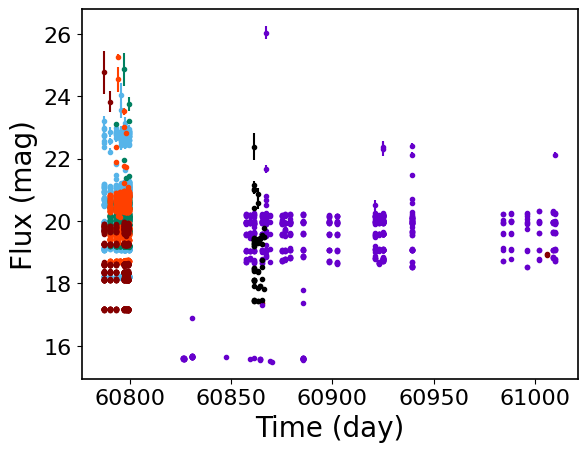

In [4]:
def load_single_band_catalog(target_band):
    cat = lsdb.open_catalog(f"processed_catalogs/top_10_{target_band}")
    return cat.compute()

def prep_single_band_catalog(cat_nf, target_band, row_index, draw_plot=True):
    # Select a row
    #print(f"row index: {row_index}")
    nf = cat_nf.iloc[[row_index]]
    
    # Cut out non-target-band observations
    nf_cut = nf.query(f"diaObjectForcedSource.band == '{target_band}'")
    
    #print(f"nf_cut has len {len(nf_cut['diaObjectForcedSource']['midpointMjdTai'])}")
    
    # Define our desired vars
    t = nf_cut["diaObjectForcedSource"]["midpointMjdTai"].to_list()
    y = nf_cut["diaObjectForcedSource"]["psfMag"].to_list()
    yerr = nf_cut["diaObjectForcedSource"]["psfMagErr"].to_list()
    diaObjectId = nf_cut["diaObjectId"].to_list()

    # Some NA values have gotten through.......this isn't really the solution,
    # but the true fix is cutting these rows back when we're selecting the top 10.
    # It's computationally uninteresting, and left as an exercise to the reader.
    # Actually, as of 3/20, I've gone back to the selection notebook and hopefully
    # it's all taken care of there
    if (
        any(pd.isna(v) for v in t)
        or any(pd.isna(v) for v in y)
        or any(pd.isna(v) for v in yerr)
    ):
        print(f"\tSkipping row {row_index} for NA values...")
        return

    # Plot
    if draw_plot:
        band = target_band
        plt.errorbar(t, y, yerr, fmt=".",  color=plot_filter_colors[band])
        plt.xlabel("Time (day)")
        plt.ylabel("Flux (mag)")

    # Print data
    if len(t) > 0:
        print(
            f"\tLC at row {row_index:>2}: "
            f"Top-10 cadence for band {target_band}, "
            f"with {len(t):>2} obs over {max(t) - min(t):.2f} days"
        )
    else:
        print(f"\tPrinting failed for band {target_band}, row {row_index}: list t is len 0!")

    return {"t": t, "y": y, "yerr": yerr, "agn_name": diaObjectId}

lightcurves = {}

for band in "ugrizy":
    cat_nf = load_single_band_catalog(band)
    lightcurves[band] = [
        lc for i in range(10)
        if (lc := prep_single_band_catalog(cat_nf, band, i)) is not None
    ]

## 2. Define ~~DHO~~ DRW Fitter

In [5]:
band, i = 'g', 0
y    = np.array(lightcurves[band][i]['y'])
yerr = np.array(lightcurves[band][i]['yerr'])
print(f"std(y)={np.std(y):.4f}, median(yerr)={np.median(yerr):.4f}, ratio={np.std(y)/np.median(yerr):.1f}")

std(y)=0.1776, median(yerr)=0.0051, ratio=34.7


In [6]:
def make_init_sampler(y_mean: float, y_std: float):
    """Returns an initSampler function with a mean prior centred on the data.
    y_mean / y_std are used to set an informative Normal prior on the mean.
    """
    def initSampler():
        # Just as in the example notebook:
        log_alpha = numpyro.sample(
            'log_alpha', dist.Uniform(low=-16.0, high=-2.0).expand([1]) # tau > ~7 days
        )
        log_beta = numpyro.sample(
            'log_beta', dist.Uniform(low=-10.0, high=2.0).expand([1])
        )
        log_kernel_param = jnp.hstack([log_alpha, log_beta])
        numpyro.deterministic('log_kernel_param', log_kernel_param)

        # But not here, we generate our mean prior based on our (real) data
        mean = numpyro.sample('mean', dist.Normal(y_mean, y_std * 2))

        return {'log_kernel_param': log_kernel_param, 'mean': mean}

    return initSampler


def fit_single_lc(t, y, yerr, fit_key, n_sample=N_SAMPLE, n_best=N_BEST):
    """Fit a single light curve with DHO MLE via random_search.
    Returns bestP dict and log-likelihood.
    """
    t    = jnp.asarray(t,    dtype=jnp.float64)
    y    = jnp.asarray(y,    dtype=jnp.float64)
    yerr = jnp.asarray(yerr, dtype=jnp.float64)

    # From the "initialize lc model" section of the example notebook:
    init_params = jnp.log(jnp.array([0.1, 1.1]))  # just alpha, beta for DRW
    k = CARMA.init(jnp.exp(init_params[:P]), jnp.exp(init_params[P:]))
    model = UniVarModel(t, y, yerr, k, zero_mean=False)

    # Note we diverge from the ex nb here, to gen. mean based on our (real) data
    y_mean = float(jnp.mean(y))
    y_std  = float(jnp.std(y))
    sampler = make_init_sampler(y_mean, y_std)

    # Then call just like we do in the example notebook
    bestP, ll = random_search(model, sampler, fit_key, n_sample, n_best)
    return bestP, ll

## 3. Run MLE Fitting on All LCs

In [7]:
results = {}   # results[band][i] = {'bestP': ..., 'll': ..., 'name': ...}

for band in BANDS:
    results[band] = []
    
    print(f"Running MLE on band {band}...")
    for i in tqdm(range(len(lightcurves[band])), desc=f'{band}-band'):
        t    = lightcurves[band][i]['t']
        y    = lightcurves[band][i]['y']
        yerr = lightcurves[band][i]['yerr']

        # Next part: Use a different key per LC to avoid correlated searches.
        
        # This is important because random_search works by randomly sampling candidate
        # parameter sets from the prior (see initSampler) and picking a number of best
        # choices with the highest likelihood.
        # If we passed the same key to all 60 fits, they'd all draw the exact same
        # 10,000 candidate points, which is no bueno when running independent searches.
        # (10,000, of whatever we set N_SAMPLE to at the top)
        band_offset = BANDS.index(band) * 100
        # Then fold_in works by taking a base key and mixing in an int to make a new,
        # deterministically derived key.
        # Note we can't do jax.random.PRNGKey(band_offset + i) directly, since keys 
        # derived this way aren't statistically independent in JAX. Apparently, low
        # integers produce correlated streams--but fold_in properly "hashes" the int
        # into key space.
        # This is a kind of "gonna take their word for it" thing for me, atm.
        lc_key = jax.random.fold_in(FIT_KEY, band_offset + i)

        try:
            bestP, ll = fit_single_lc(t, y, yerr, lc_key)
            results[band].append({
                'name':  lightcurves[band][i]['agn_name'],
                'bestP': bestP,
                'll':    float(ll),
                'status': 'ok',
            })
        except Exception as e:
            print(f'  WARNING: fit failed for {band} AGN_{i}: {e}')
            results[band].append({
                'name':  lightcurves[band][i]['agn_name'],
                'bestP': None,
                'll': np.nan,
                'status': f'failed: {e}',
            })

print('\nAll fits complete.')

Running MLE on band u...


u-band:   0%|          | 0/10 [00:00<?, ?it/s]

Running MLE on band g...


g-band:   0%|          | 0/10 [00:00<?, ?it/s]

Running MLE on band r...


...

Running MLE on band z...


z-band:   0%|          | 0/10 [00:00<?, ?it/s]

Running MLE on band y...


y-band:   0%|          | 0/10 [00:00<?, ?it/s]


All fits complete.


## 4. Compute Structure Functions from MLE Parameters

In [8]:
def sf_from_params(log_kernel_param, taus):
    """Compute SF at given time lags from log_kernel_param vector."""
    # MLE stores things in log-space (as log_kernel_param), so we 
    # need to exponentiate before passing to CARMA.init
    params = jnp.exp(log_kernel_param)
    
    # Create second-order stat object (from the second-order stats section of ex nb)
    dho_k = CARMA.init(params[:P], params[P:])
    stat = gpStat2(dho_k)
    return stat.sf(taus)


# Timescale grid for plots
ts_grid = jnp.logspace(0, 4, 200)

# Store SF values
sf_10   = {}   # SF at tau = 10 days
sf_inf  = {}   # SF at tau -> inf (asymptotic variance proxy)
               # "The SF of a stationary process like the DHO plateaus at large lags:
               # it stops growing and flattens out because the process loses memory of itself."
               # This in theory is a measure of the -total- intrinsic variability amplitude
               # with no timescale dependence (for answering Q2 - rank AGN within a band to 
               # find the most variable one overall).
sf_grid = {}   # full SF curve for plotting

for band in BANDS:
    sf_10[band]   = []
    sf_inf[band]  = []
    sf_grid[band] = []

    for res in results[band]:
        if res['status'] != 'ok':
            sf_10[band].append(np.nan)
            sf_inf[band].append(np.nan)
            sf_grid[band].append(None)
            continue

        lkp = res['bestP']['log_kernel_param']
        sf_10[band].append(float(sf_from_params(lkp, TAU_10)[0]))
        sf_inf[band].append(float(sf_from_params(lkp, TAU_INF)[0]))
        sf_grid[band].append(np.array(sf_from_params(lkp, ts_grid)))

print('Structure functions computed.')

Structure functions computed.


## 5. Question 1 — Which Band is Most Variable on ~10-day Timescale?

In [9]:
q1_rows = []
for band in BANDS:
    vals = [v for v in sf_10[band] if not np.isnan(v)]
    q1_rows.append({
        'Band':        band,
        'SF(τ=10) median': np.median(vals) if vals else np.nan,
        'SF(τ=10) mean':   np.mean(vals)   if vals else np.nan,
        'SF(τ=10) min':    np.min(vals)     if vals else np.nan,
        'SF(τ=10) max':    np.max(vals)     if vals else np.nan,
        'N fits OK':       len(vals),
    })

q1_df = pd.DataFrame(q1_rows).set_index('Band')
print('SF(τ=10 days) summary per band:\n')
display(q1_df.sort_values('SF(τ=10) median', ascending=False))

SF(τ=10 days) summary per band:



,SF(τ=10) median,SF(τ=10) mean,SF(τ=10) min,SF(τ=10) max,N fits OK
Band,,,,,
r,0.286015,0.309734,0.082642,0.647613,10
z,0.207991,0.293980,0.000004,1.019621,10
g,0.111044,0.210078,0.022568,0.541418,10
u,0.068490,0.091436,0.000037,0.344448,10
y,0.036462,0.091016,0.000013,0.501719,10
i,0.021992,0.036249,0.000004,0.100030,9


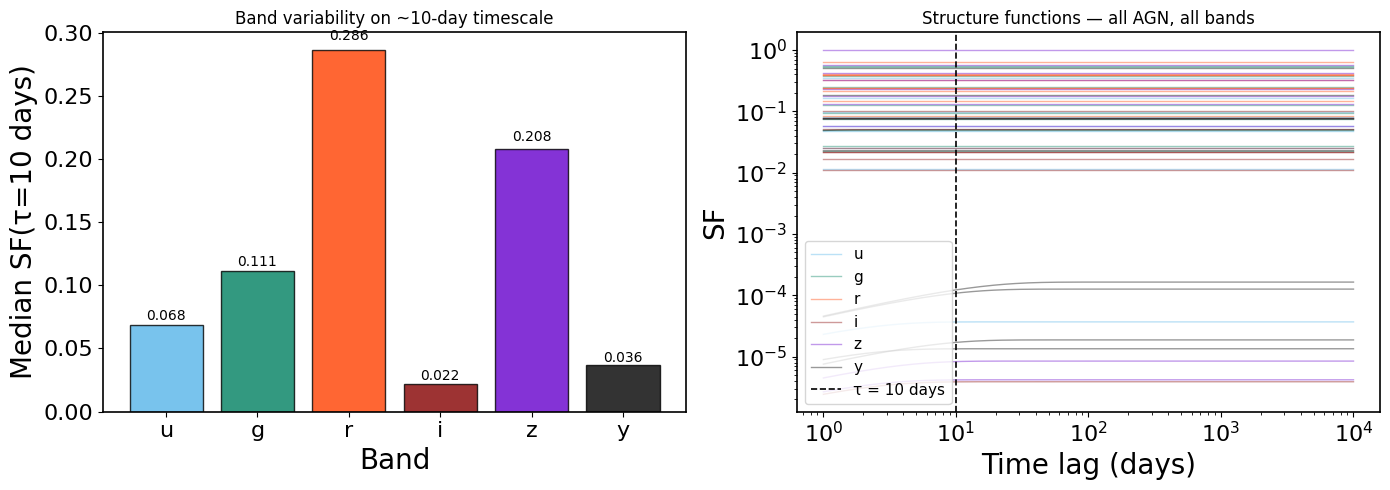


→ Most variable band at τ=10 days: r


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of median SF(tau = 10) per band
ax = axes[0]
medians = [np.nanmedian(sf_10[b]) for b in BANDS]
band_colors = [
'#56b4e9',  # light blue
'#008060',  # teal/green
'#ff4000',  # red-orange
'#850000',  # dark red
'#6600cc',  # purple
'#000000'   # black
]
bars = ax.bar(BANDS, medians, color=band_colors, alpha=0.8, edgecolor='k')
ax.set_xlabel('Band')
ax.set_ylabel('Median SF(τ=10 days)')
ax.set_title('Band variability on ~10-day timescale')
for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, val * 1.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

# Right: full SF curves per band (all AGN, coloured by band)
ax = axes[1]
for band, color in zip(BANDS, band_colors):
    for j, curve in enumerate(sf_grid[band]):
        if curve is not None:
            label = band if j == 0 else None
            ax.loglog(ts_grid, curve, color=color, alpha=0.4, lw=1, label=label)
ax.axvline(10, color='k', ls='--', lw=1.2, label='τ = 10 days')
ax.set_xlabel('Time lag (days)')
ax.set_ylabel('SF')
ax.set_title('Structure functions — all AGN, all bands')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('q1_band_variability.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n→ Most variable band at τ=10 days: {BANDS[int(np.argmax(medians))]}")

## 6. Question 2 — Which AGN is Most Variable in Each Band?

In [11]:
q2_rows = []
for band in BANDS:
    vals = np.array(sf_inf[band])
    names = [r['name'] for r in results[band]]
    best_idx = int(np.nanargmax(vals))
    for i, (name, v) in enumerate(zip(names, vals)):
        q2_rows.append({
            'Band':     band,
            'AGN':      name,
            'SF(τ→∞)':  v,
            'Most variable': '★' if i == best_idx else '',
        })

q2_df = pd.DataFrame(q2_rows)
print('SF(τ→∞) per AGN per band:\n')
display(q2_df)

SF(τ→∞) per AGN per band:



,Band,AGN,SF(τ→∞),Most variable
0,u,[74247340164120613],0.082298,
1,u,[74239093826912267],0.011626,
...,...,...,...,...
57,y,[41944169576399765],0.077022,
58,y,[41945475246457862],0.074628,


In [12]:
print('Most variable AGN in each band (by asymptotic SF):\n')
for band in BANDS:
    vals  = np.array(sf_inf[band])
    names = [r['name'] for r in results[band]]
    best  = names[int(np.nanargmax(vals))]
    print(f'  {band}: {best}  (SF→∞ = {np.nanmax(vals):.4f})')

Most variable AGN in each band (by asymptotic SF):

  u: [74247821200457879]  (SF→∞ = 0.3444)
  g: [74247271444644463]  (SF→∞ = 0.5414)
  r: [74247271444644463]  (SF→∞ = 0.6476)
  i: [74245690896679513]  (SF→∞ = 0.1000)
  z: [19772998638632968]  (SF→∞ = 1.0196)
  y: [41936198117098075]  (SF→∞ = 0.5017)


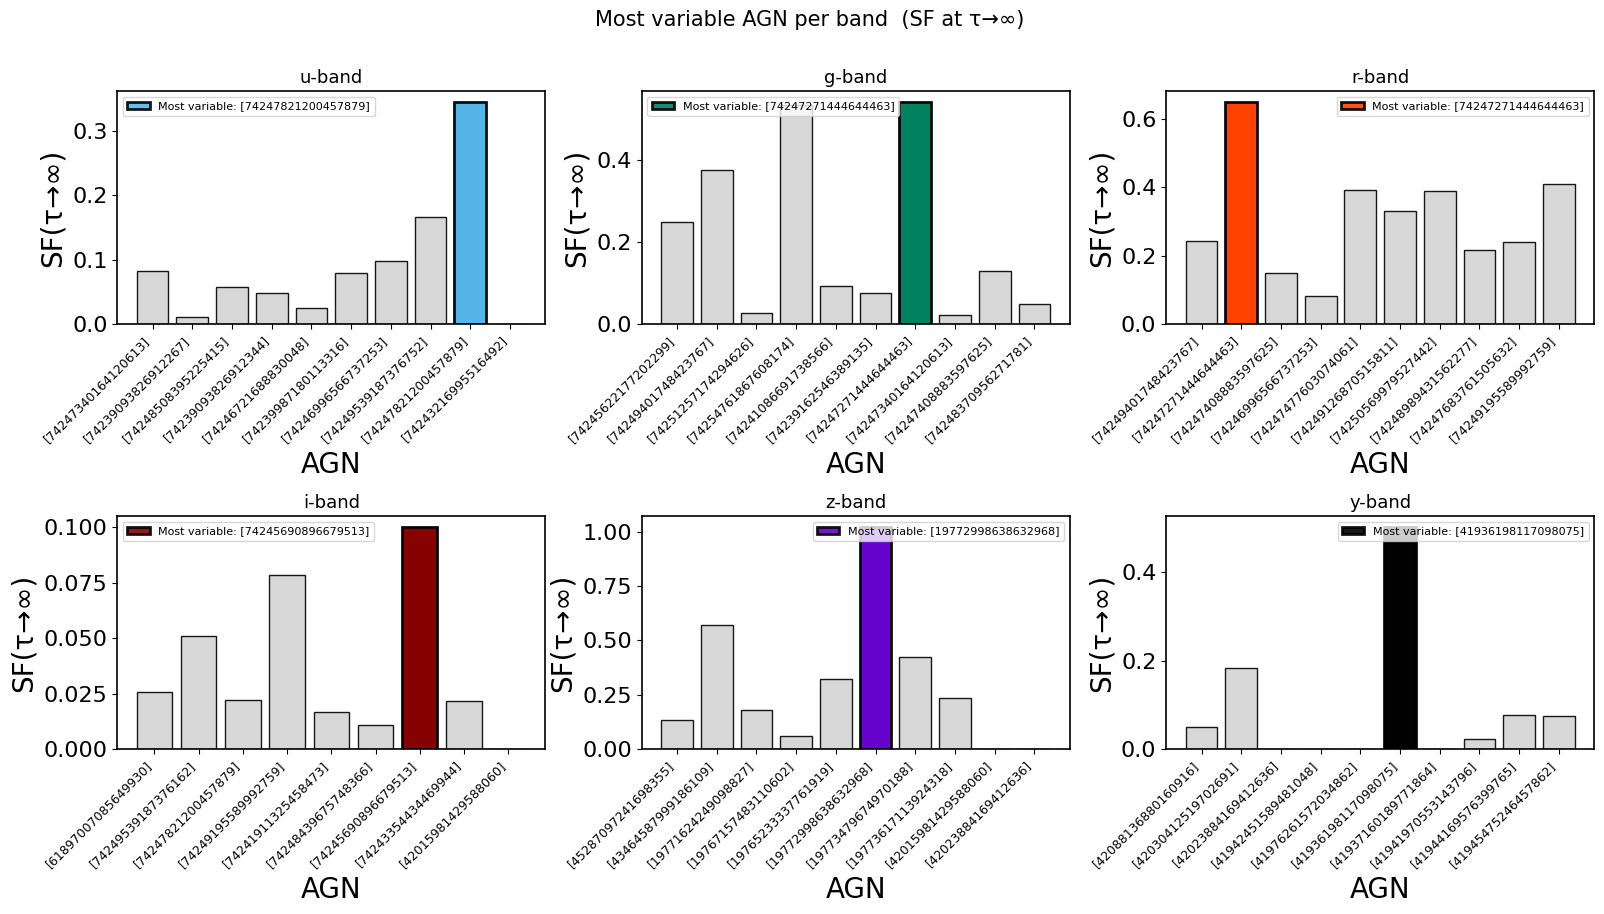

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flatten()

for ax, (band, color) in zip(axes, zip(BANDS, band_colors)):
    names  = [r['name'] for r in results[band]]
    vals   = np.array(sf_inf[band])
    n_agn  = len(results[band])  # actual count, not assumed N_AGN

    best_idx   = int(np.nanargmax(vals))
    bar_colors = [color if i == best_idx else 'lightgrey' for i in range(n_agn)]

    ax.bar(range(n_agn), vals, color=bar_colors, edgecolor='k', alpha=0.9)
    ax.bar(best_idx, vals[best_idx], color=color, edgecolor='k',
           linewidth=2, alpha=0.9, label=f'Most variable: {names[best_idx]}')
    ax.set_xticks(range(n_agn))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'{band}-band', fontsize=13)
    ax.set_ylabel('SF(τ→∞)')
    ax.set_xlabel('AGN')
    ax.legend(fontsize=8)

plt.suptitle('Most variable AGN per band  (SF at τ→∞)', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('q2_most_variable_agn.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Diagnostic Plots — Light Curve Fits

For each LC, plot the data with the GP mean prediction using the MLE parameters.

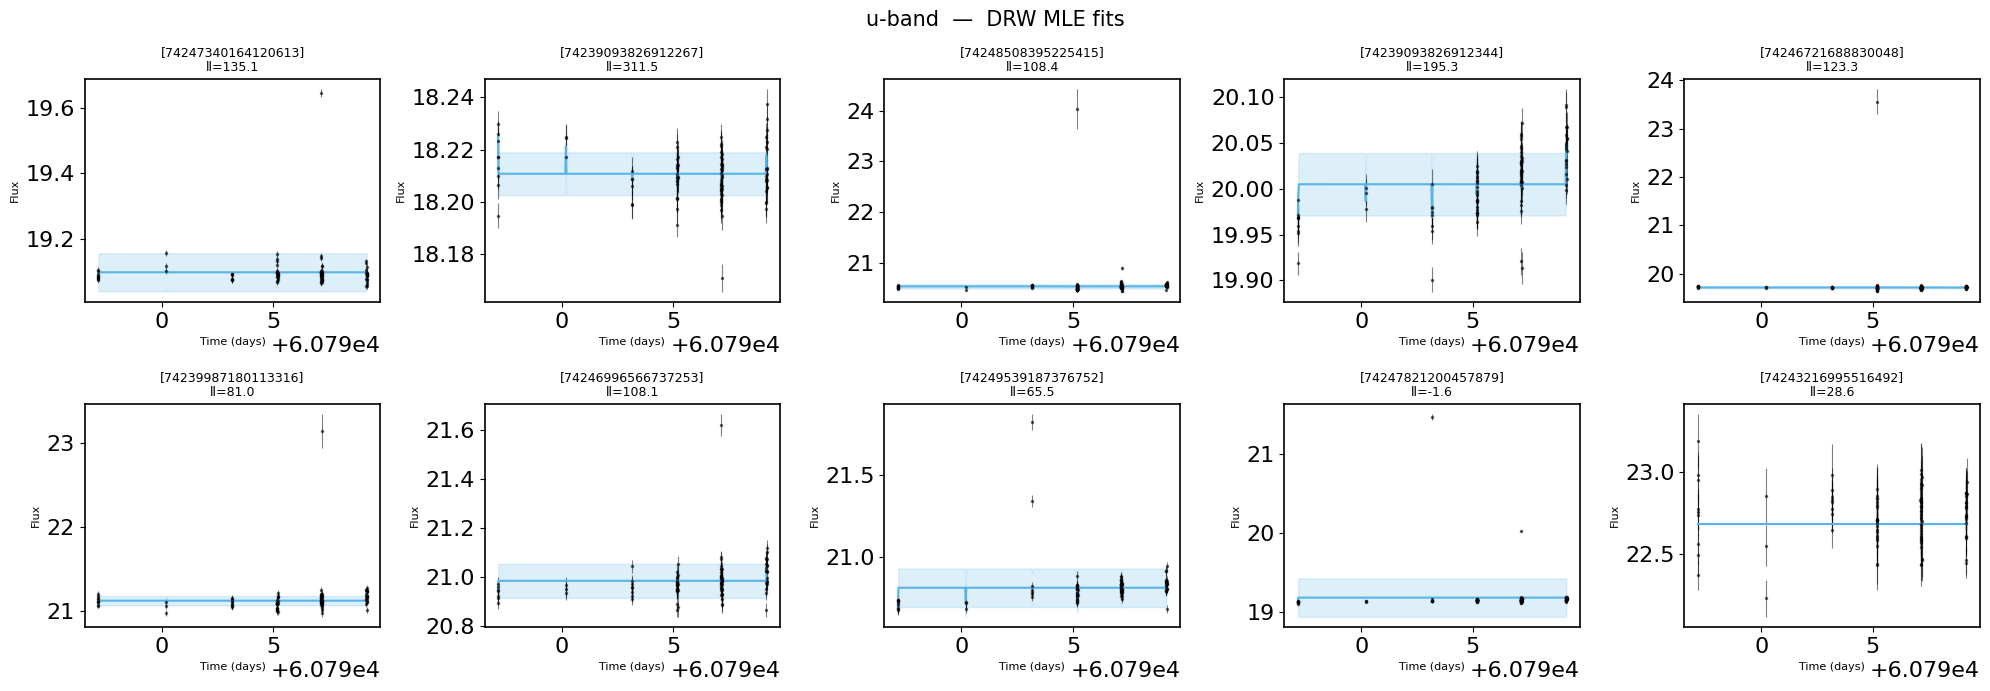

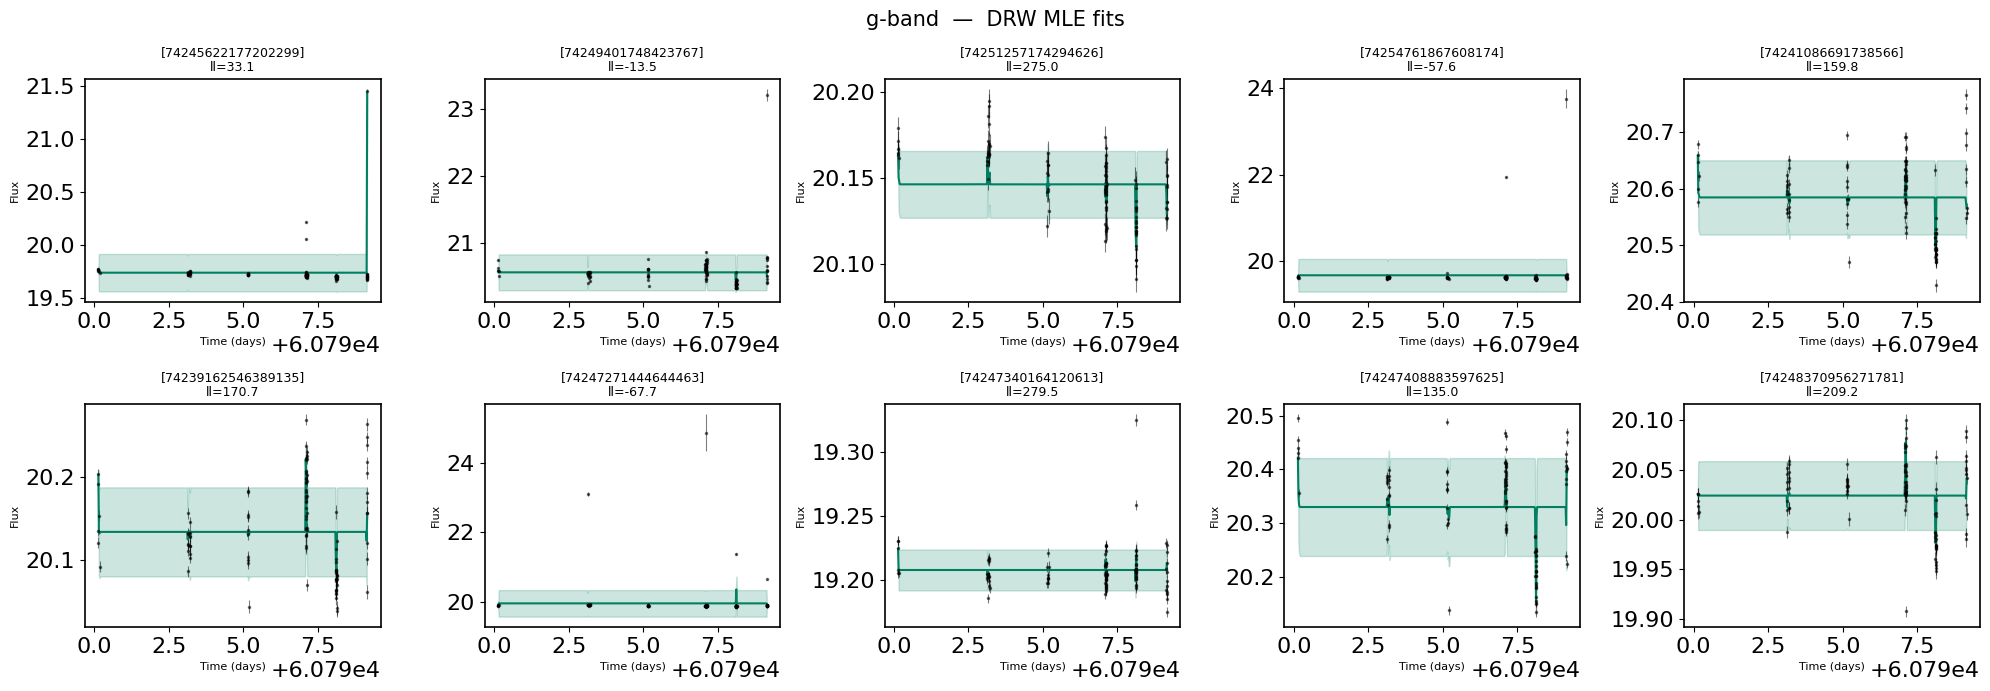

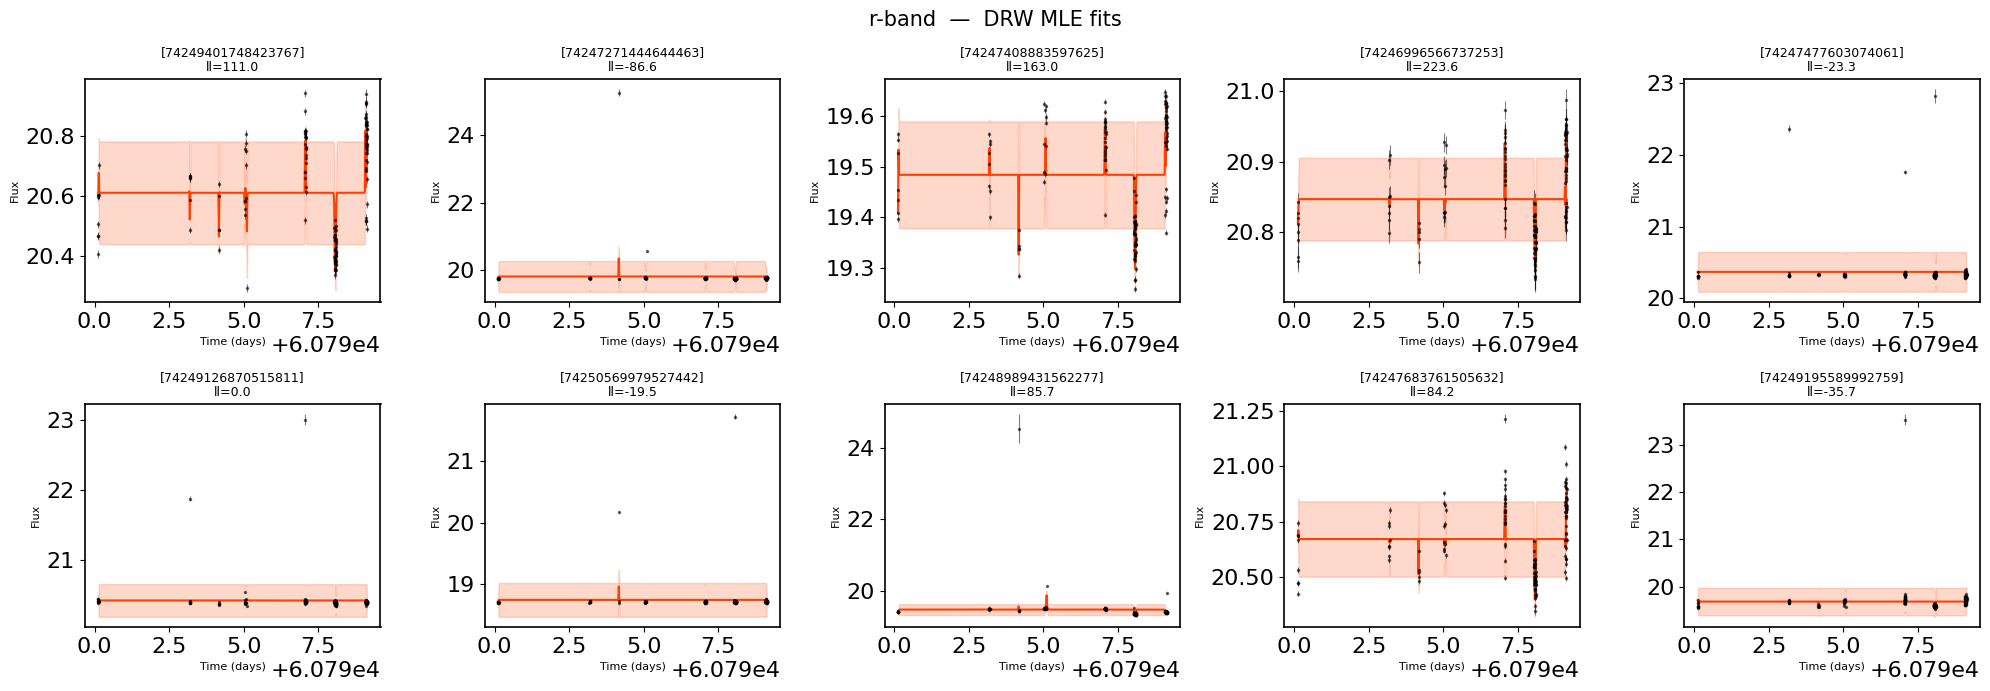

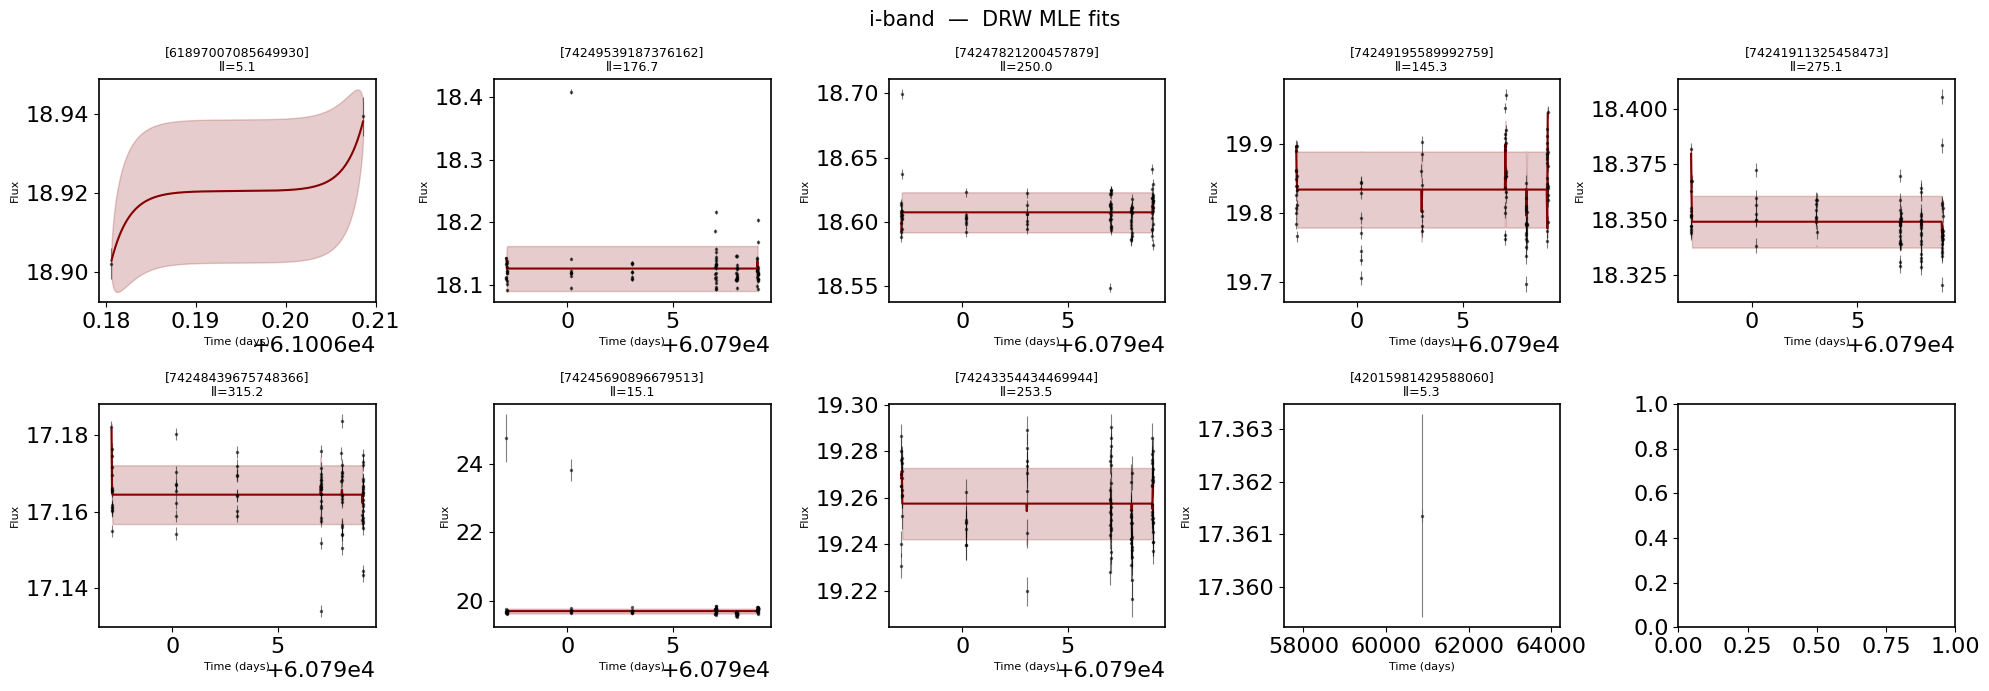

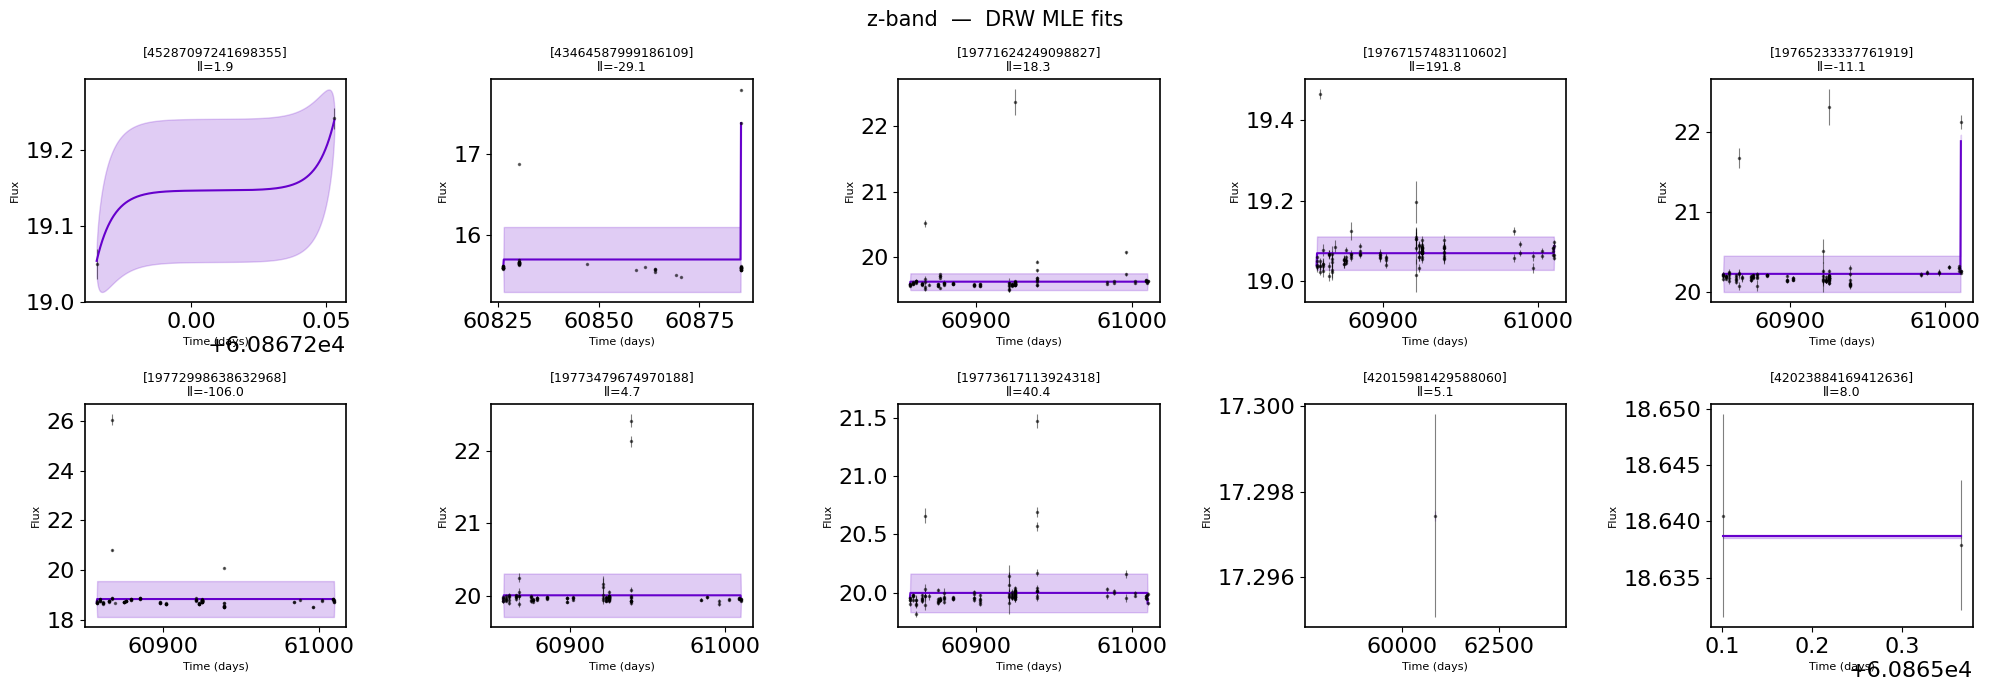

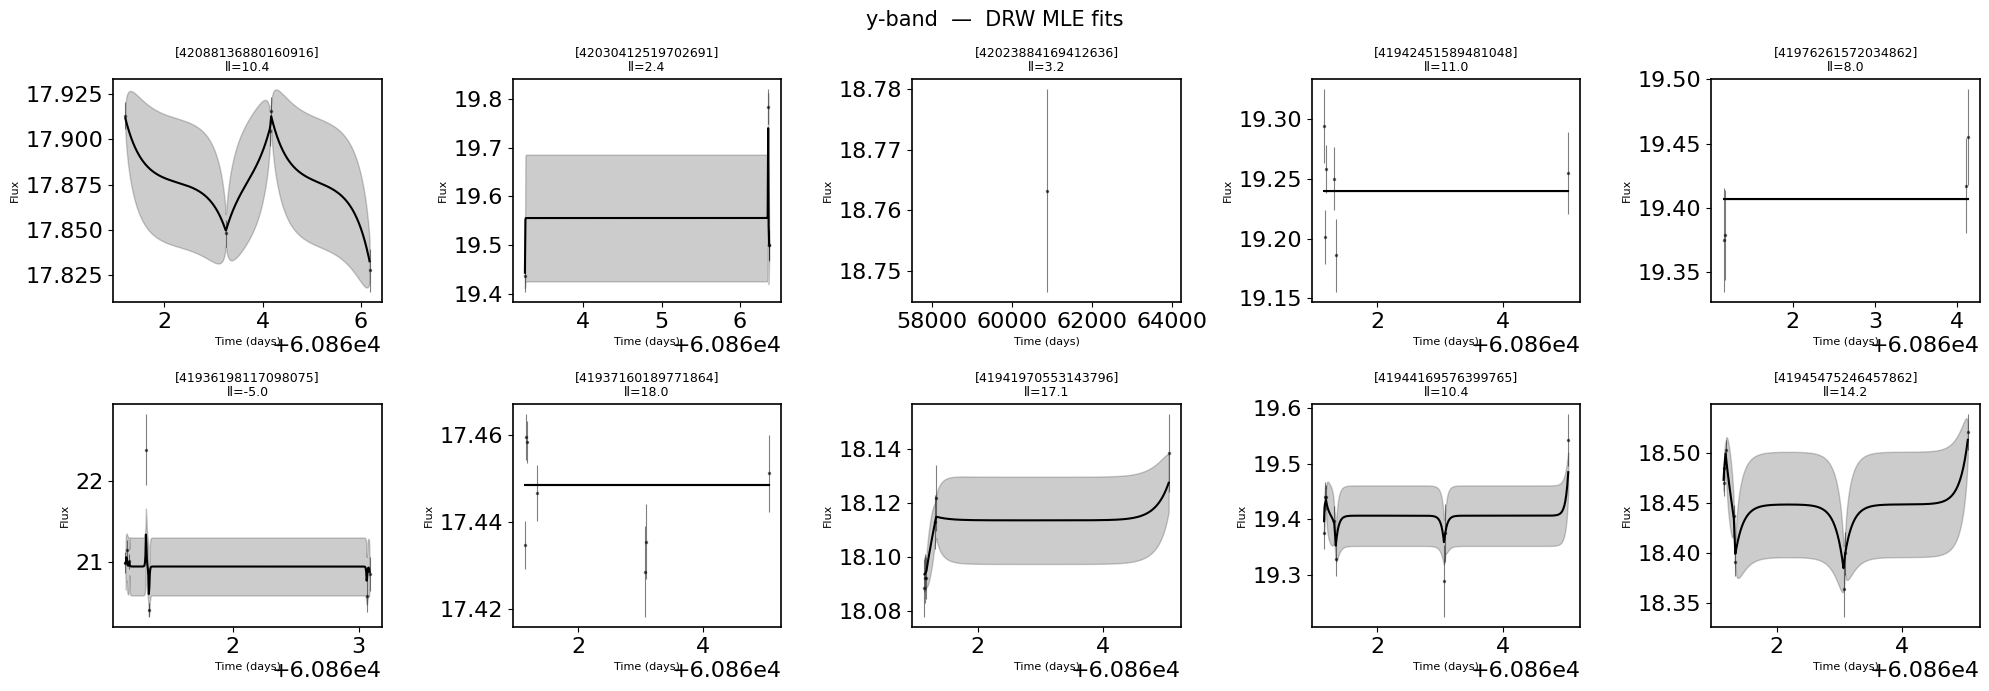

In [17]:
def predict_gp(t, y, yerr, log_kernel_param, mean_val, t_pred=None):
    """
    Return GP posterior mean and std at t_pred using MLE parameters.
    If t_pred is None, uses a dense grid over the data range.
    """
    t    = jnp.asarray(t,    dtype=jnp.float64)
    y    = jnp.asarray(y,    dtype=jnp.float64)
    yerr = jnp.asarray(yerr, dtype=jnp.float64)
    sort_idx = jnp.argsort(t)
    t, y, yerr = t[sort_idx], y[sort_idx], yerr[sort_idx]

    if t_pred is None:
        t_pred = jnp.linspace(t.min(), t.max(), 500)

    params = jnp.exp(log_kernel_param)
    k = CARMA.init(params[:P], params[P:])
    m = UniVarModel(t, y - mean_val, yerr, k, zero_mean=True)

    gp = m.build_gp({'log_kernel_param': log_kernel_param, 'mean': jnp.array(0.0)})
    _, cond = gp.condition(y - mean_val, t_pred)
    mu  = np.array(cond.loc) + mean_val
    std = np.array(jnp.sqrt(cond.variance))
    return np.array(t_pred), mu, std, np.array(t), np.array(y), np.array(yerr)


for band, color in zip(BANDS, band_colors):
    fig, axes = plt.subplots(2, 5, figsize=(20, 7), sharey=False)
    axes = axes.flatten()
    fig.suptitle(f'{band}-band  —  DRW MLE fits', fontsize=15)

    for i, (res, ax) in enumerate(zip(results[band], axes)):
        t    = lightcurves[band][i]['t']
        y    = lightcurves[band][i]['y']
        yerr = lightcurves[band][i]['yerr']
        name = res['name']

        ax.set_title(f"{name}\nll={res['ll']:.1f}" if res['status'] == 'ok'
                     else f"{name}\nFAILED", fontsize=9)
        ax.errorbar(t, y, yerr, fmt='.', color='k', alpha=0.5,
                    ms=3, elinewidth=0.8, label='data')

        if res['status'] == 'ok':
            lkp      = res['bestP']['log_kernel_param']
            mean_val = float(res['bestP']['mean'])
            
            t_arr  = jnp.asarray(t, dtype=jnp.float64)
            y_arr  = jnp.asarray(y, dtype=jnp.float64)
            yerr_arr = jnp.asarray(yerr, dtype=jnp.float64)
            
            params = res['bestP']
            k = CARMA.init(jnp.exp(lkp[:P]), jnp.exp(lkp[P:]))
            m = UniVarModel(t_arr, y_arr, yerr_arr, k, zero_mean=False)
            
            t_pred = jnp.linspace(t_arr.min(), t_arr.max(), 500)
            mu, std = m.pred(params, t_pred)
            
            ax.plot(np.array(t_pred), np.array(mu), color=color, lw=1.5, label='GP mean')
            ax.fill_between(np.array(t_pred), np.array(mu - std), np.array(mu + std),
                            color=color, alpha=0.2, label='±1σ')

        ax.set_xlabel('Time (days)', fontsize=8)
        ax.set_ylabel('Flux', fontsize=8)

    plt.tight_layout()
    plt.savefig(f'fits_{band}.png', dpi=120, bbox_inches='tight')
    plt.show()

## Adding MCMC

In [18]:
# Pick the most variable AGN per band by sf_inf (reuses MLE results)
mcmc_targets = {}
for band in BANDS:
    vals  = np.array(sf_inf[band])
    best_idx = int(np.nanargmax(vals))
    mcmc_targets[band] = {
        'idx':  best_idx,
        'name': results[band][best_idx]['name'],
        't':    lightcurves[band][best_idx]['t'],
        'y':    lightcurves[band][best_idx]['y'],
        'yerr': lightcurves[band][best_idx]['yerr'],
    }
    print(f"{band}: {mcmc_targets[band]['name']}  (SF→∞ = {vals[best_idx]:.4f})")

u: [74247821200457879]  (SF→∞ = 0.3444)
g: [74247271444644463]  (SF→∞ = 0.5414)
r: [74247271444644463]  (SF→∞ = 0.6476)
i: [74245690896679513]  (SF→∞ = 0.1000)
z: [19772998638632968]  (SF→∞ = 1.0196)
y: [41936198117098075]  (SF→∞ = 0.5017)


In [19]:
def make_numpyro_model(t, y, yerr):
    """Returns a numpyro model function closed over a specific LC's data."""
    t    = jnp.asarray(t,    dtype=jnp.float64)
    y    = jnp.asarray(y,    dtype=jnp.float64)
    yerr = jnp.asarray(yerr, dtype=jnp.float64)
    sort_idx = jnp.argsort(t)
    t, y, yerr = t[sort_idx], y[sort_idx], yerr[sort_idx]

    y_mean = float(jnp.mean(y))
    y_std  = float(jnp.std(y))

    def numpyro_model():
        log_alpha = numpyro.sample(
            'log_alpha', dist.Uniform(low=-16.0, high=-2.0).expand([1])
        )
        log_beta = numpyro.sample(
            'log_beta', dist.Uniform(low=-10.0, high=2.0).expand([1])
        )
        log_kernel_param = jnp.hstack([log_alpha, log_beta])
        numpyro.deterministic('log_kernel_param', log_kernel_param)

        mean = numpyro.sample('mean', dist.Normal(y_mean, y_std * 2))
        sample_params = {'log_kernel_param': log_kernel_param, 'mean': mean}

        k = CARMA.init(jnp.exp(log_kernel_param[:P]), jnp.exp(log_kernel_param[P:]))
        m = UniVarModel(t, y, yerr, k, zero_mean=False)
        m.sample(sample_params)

    return numpyro_model

In [20]:
import arviz as az
from numpyro.infer import MCMC, NUTS

mcmc_results = {}  # mcmc_results[band] = {'data': az.InferenceData, 'name': str}

for band in BANDS:
    target = mcmc_targets[band]
    print(f"\n── {band}-band: {target['name']} ──")

    numpyro_model = make_numpyro_model(
        target['t'], target['y'], target['yerr']
    )

    nuts_kernel = NUTS(
        numpyro_model,
        dense_mass=True,
        target_accept_prob=0.9,
        init_strategy=numpyro.infer.init_to_sample,
    )
    mcmc = MCMC(
        nuts_kernel,
        num_warmup=2000,
        num_samples=4000,
        num_chains=1,
    )
    mcmc.run(jax.random.PRNGKey(BANDS.index(band)))
    mcmc.print_summary()

    mcmc_results[band] = {
        'data': az.from_numpyro(mcmc),
        'name': target['name'],
    }

print('\nAll MCMC runs complete.')


── u-band: [74247821200457879] ──


sample: 100%|██████████| 6000/6000 [00:04<00:00, 1259.63it/s, 7 steps of size 3.90e-01. acc. prob=0.97] 



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
log_alpha[0]     -3.67      1.84     -3.02     -6.12     -2.00   3072.64      1.00
 log_beta[0]      1.98      0.02      1.99      1.96      2.00   3340.78      1.00
        mean     19.18      0.48     19.18     18.39     19.96   2978.66      1.00

Number of divergences: 0

── g-band: [74247271444644463] ──


sample: 100%|██████████| 6000/6000 [00:04<00:00, 1332.48it/s, 7 steps of size 4.87e-01. acc. prob=0.94] 



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
log_alpha[0]     -3.79      1.92     -3.14     -6.35     -2.00   3333.24      1.00
 log_beta[0]      1.99      0.01      2.00      1.99      2.00   4043.45      1.00
        mean     20.01      1.23     20.01     18.12     22.23   2934.63      1.00

Number of divergences: 0

── r-band: [74247271444644463] ──


...


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
log_alpha[0]     -3.75      1.89     -3.12     -6.15     -2.00   3678.50      1.00
 log_beta[0]      0.74      0.08      0.74      0.60      0.87   3048.92      1.00
        mean     19.75      1.30     19.75     17.51     21.83   3919.14      1.00

Number of divergences: 0

── z-band: [19772998638632968] ──


sample: 100%|██████████| 6000/6000 [00:04<00:00, 1304.56it/s, 3 steps of size 5.61e-01. acc. prob=0.92]



                  mean       std    median      5.0%     95.0%     n_eff     r_hat
log_alpha[0]     -2.24      0.34     -2.15     -2.53     -2.00   2666.49      1.00
 log_beta[0]      2.00      0.00      2.00      1.99      2.00   3574.47      1.00
        mean     18.88      1.43     18.89     16.66     21.37   3135.97      1.00

Number of divergences: 0

── y-band: [41936198117098075] ──


sample: 100%|██████████| 6000/6000 [00:04<00:00, 1457.24it/s, 3 steps of size 2.54e-01. acc. prob=0.97] 


                  mean       std    median      5.0%     95.0%     n_eff     r_hat
log_alpha[0]     -4.00      1.94     -3.41     -6.59     -2.00   2467.73      1.00
 log_beta[0]      0.29      0.72      0.23     -0.88      1.43   1414.05      1.00
        mean     21.04      1.09     21.03     19.29     22.82   2292.69      1.00

Number of divergences: 0

All MCMC runs complete.


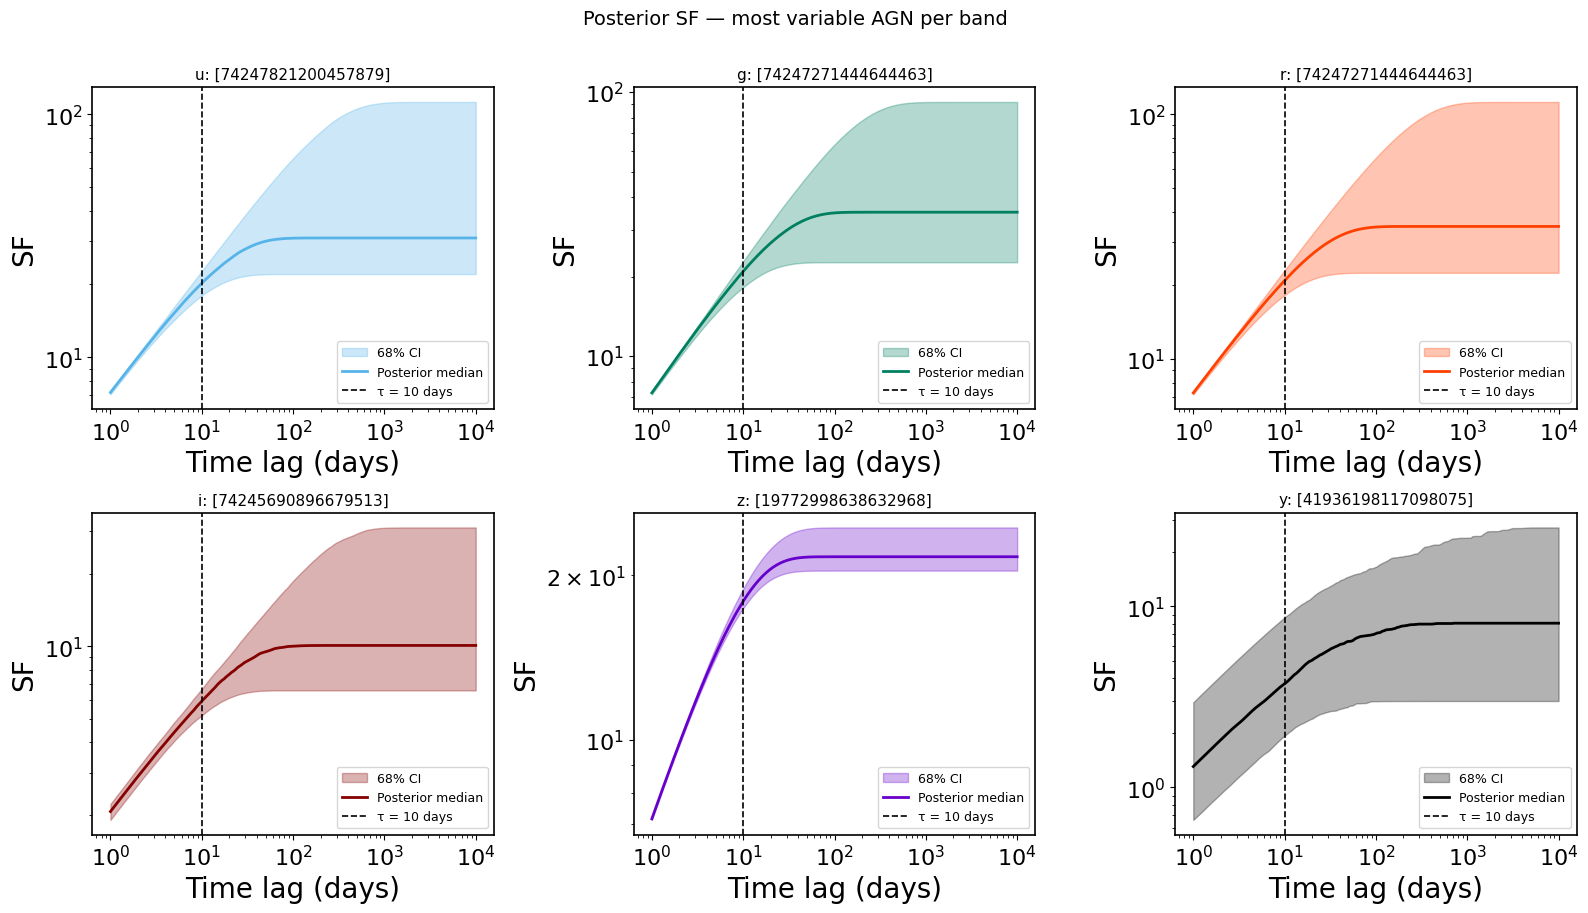

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (band, color) in zip(axes, zip(BANDS, band_colors)):
    idata = mcmc_results[band]['data']
    name  = mcmc_results[band]['name']

    # Extract posterior draws
    flat_post = idata.posterior.ds.stack(sample=['chain', 'draw'])
    log_carma_draws = flat_post['log_kernel_param'].values.T  # shape (n_draws, 2)

    # Compute SF for each draw
    mcmc_sf = np.array([
        sf_from_params(jnp.asarray(draw), ts_grid)
        for draw in log_carma_draws[::10]  # thin by 10 for speed
    ])

    # Plot posterior envelope
    sf_median = np.median(mcmc_sf, axis=0)
    sf_lo     = np.percentile(mcmc_sf, 16, axis=0)
    sf_hi     = np.percentile(mcmc_sf, 84, axis=0)

    ax.fill_between(ts_grid, sf_lo, sf_hi, color=color, alpha=0.3, label='68% CI')
    ax.loglog(ts_grid, sf_median, color=color, lw=2, label='Posterior median')
    ax.axvline(10, color='k', ls='--', lw=1.2, label='τ = 10 days')

    ax.set_xlabel('Time lag (days)')
    ax.set_ylabel('SF')
    ax.set_title(f'{band}: {name}', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Posterior SF — most variable AGN per band', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('mcmc_sf_posterior.png', dpi=150, bbox_inches='tight')
plt.show()

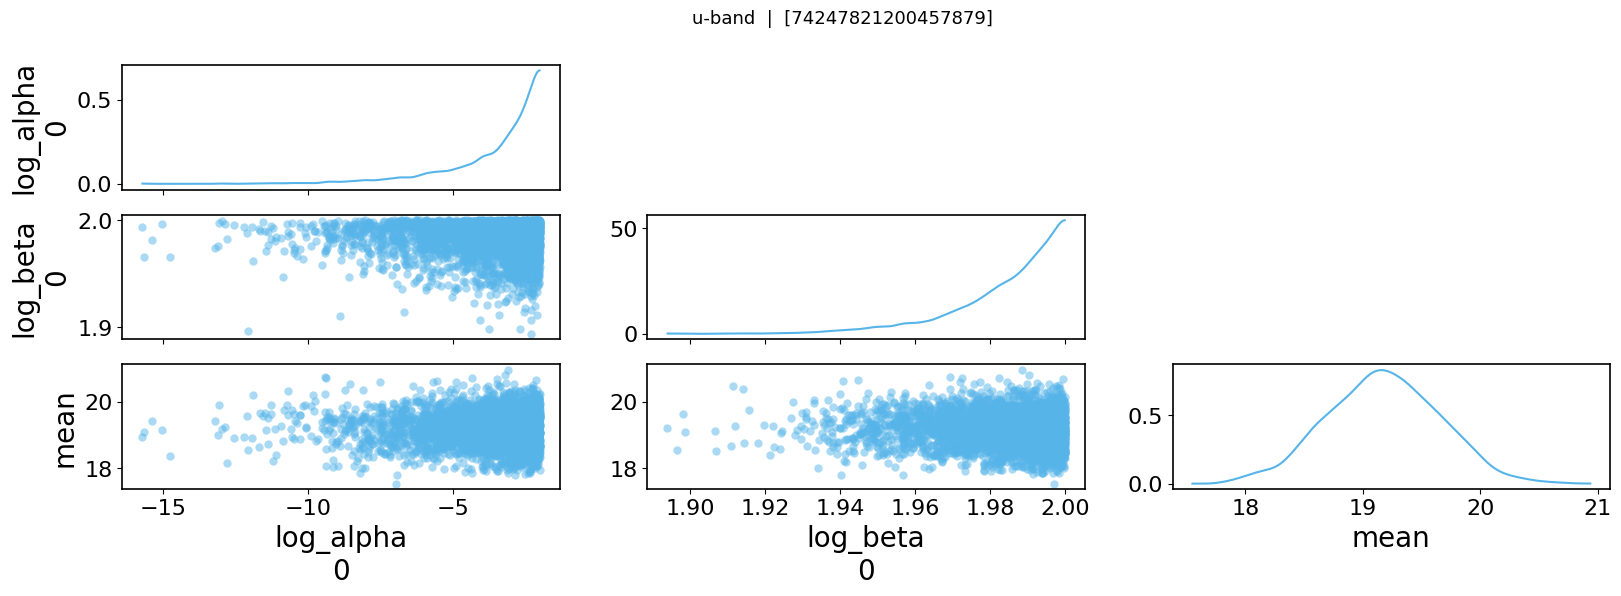

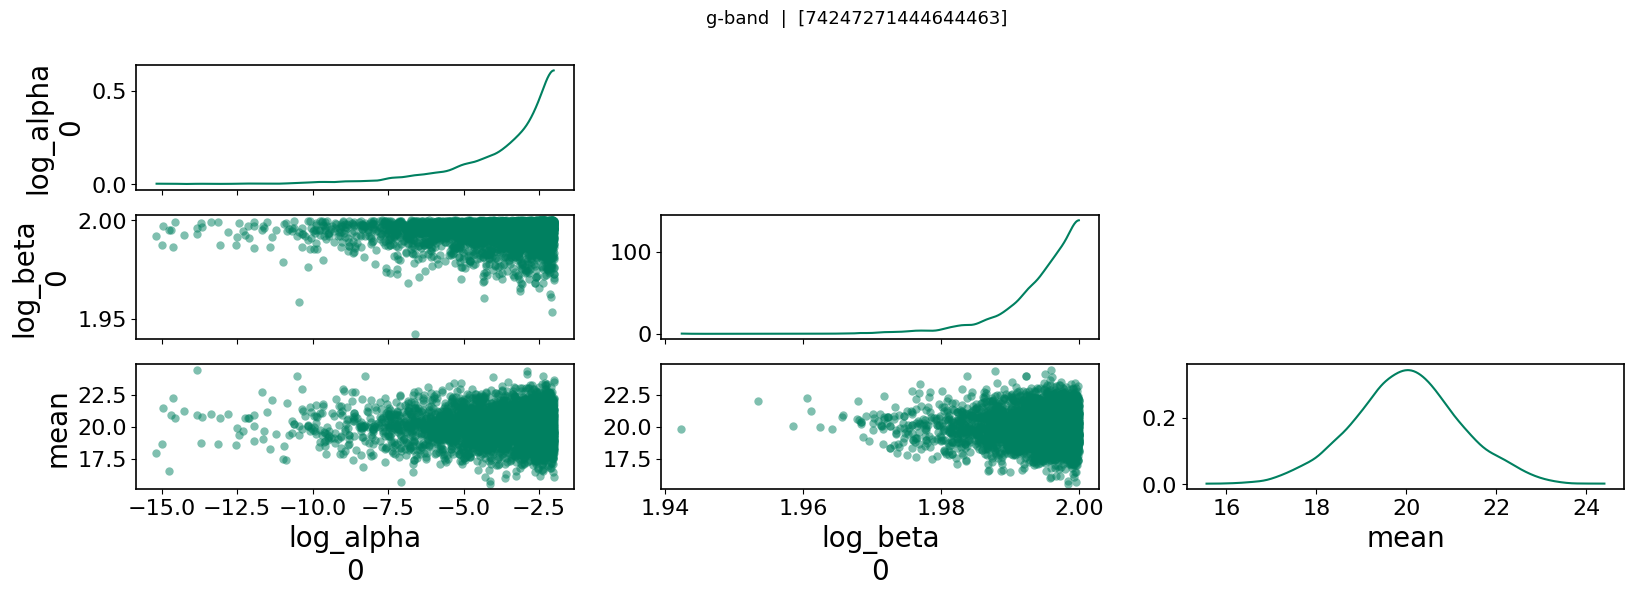

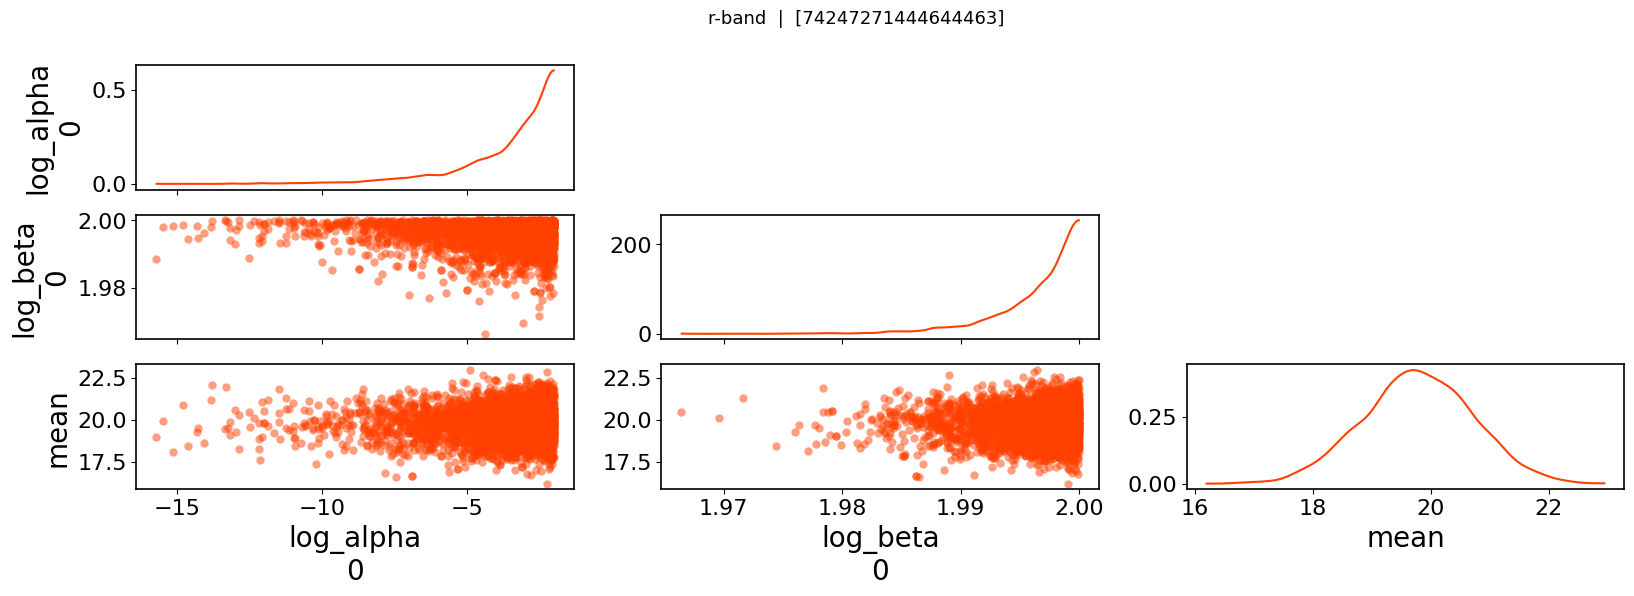

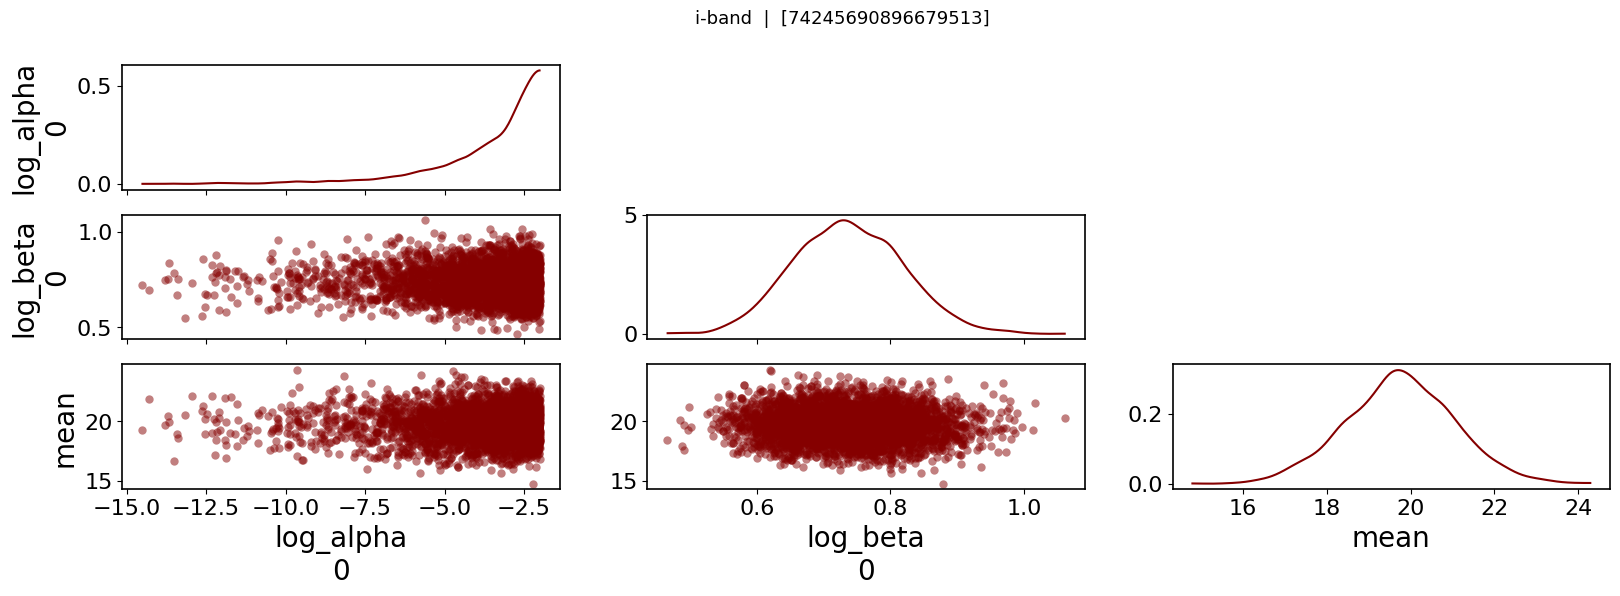

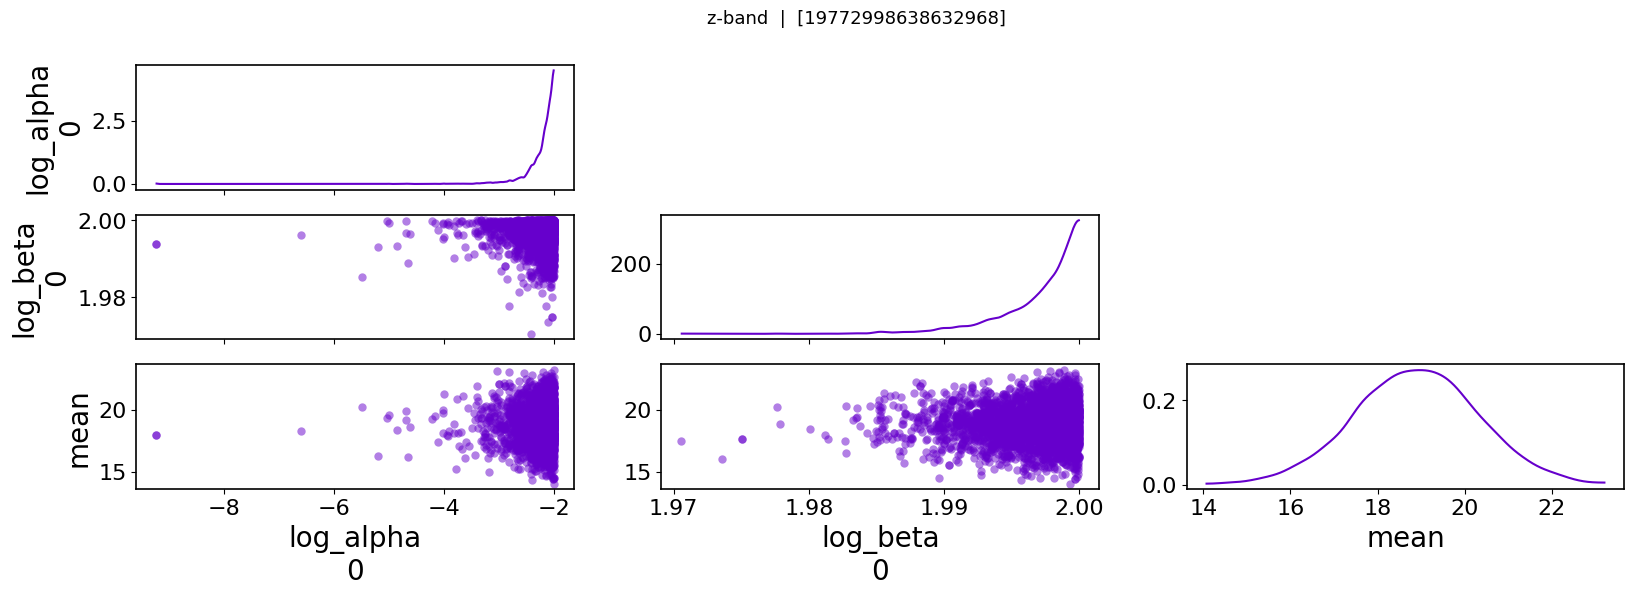

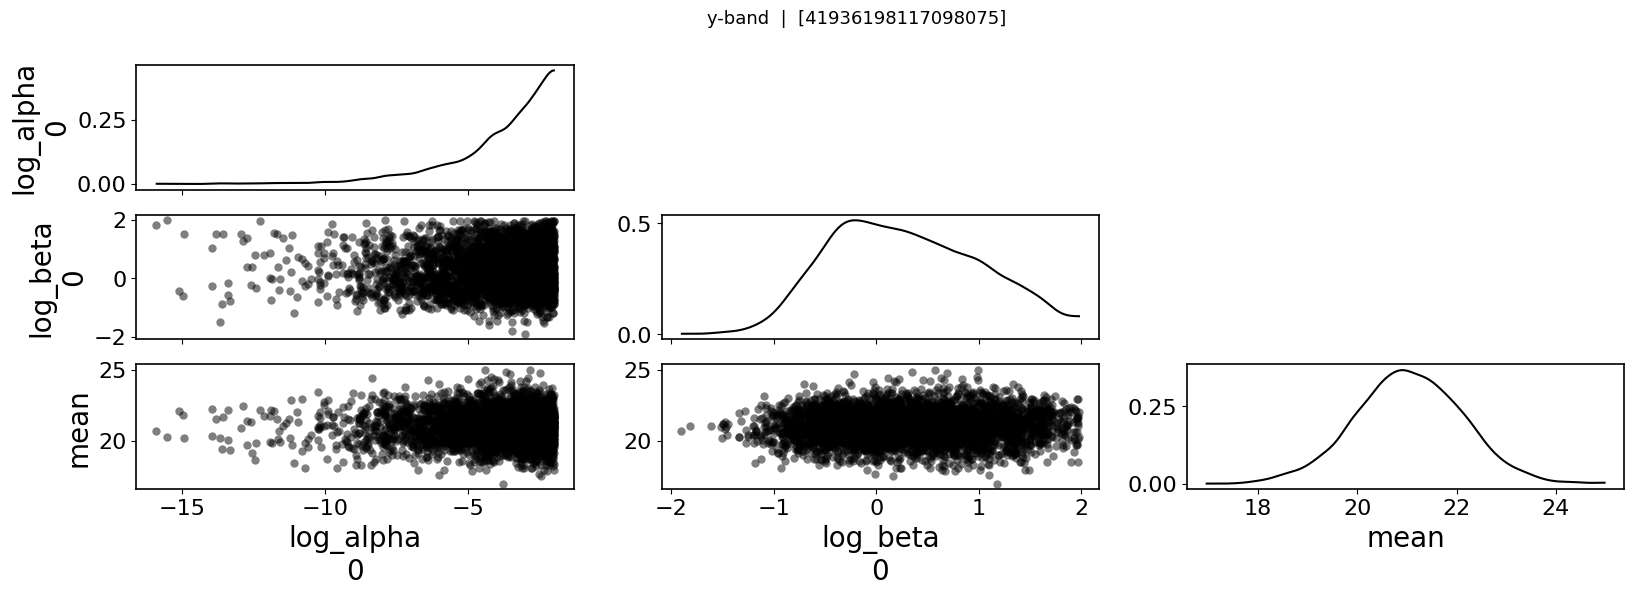

In [32]:
for band in BANDS:
    idata = mcmc_results[band]['data']
    name  = mcmc_results[band]['name']
    color = plot_filter_colors[band]

    az.plot_pair(
        idata,
        var_names=['log_alpha', 'log_beta', 'mean'],
        marginal=True,        # was 'marginals'
        triangle='lower',     # replaces 'kind'
        visuals={
            'scatter': {'color': color},
            'dist':    {'color': color},
        }
    )
    plt.suptitle(f'{band}-band  |  {name}', fontsize=13)
    plt.savefig(f'mcmc_corner_{band}.png', dpi=120, bbox_inches='tight')
    plt.show()